In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/house-prices-advanced-regression-techniques/test.csv


In [2]:
#Importing important lib

In [3]:
import matplotlib.pyplot as plt 
import seaborn as sns
import calendar 
from pandas.api.types import CategoricalDtype
from sklearn.preprocessing import StandardScaler

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [4]:
#load data from csv format 

In [5]:
test_data="/kaggle/input/house-prices-advanced-regression-techniques/test.csv"
train_data="/kaggle/input/house-prices-advanced-regression-techniques/train.csv"

pd.read_csv(train_data)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [6]:
#now we are saving both files train and test data in other variable as well

In [7]:
train=pd.read_csv(train_data)
test=pd.read_csv(test_data)

In [8]:
#shape file of train 

In [9]:
print("Shape of train data: ", train.shape)


Shape of train data:  (1460, 81)


In [10]:
#shape file of Test 

In [11]:
print("Shape of test data: ", test.shape)

Shape of test data:  (1459, 80)


In [12]:
#head of top 5 entites

In [13]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [14]:
#show all rows and columns or customized  None is used for all columns and rows shows 

In [15]:
pd.set_option("display.max.columns", None)
pd.set_option("display.max.rows", None)

In [16]:
test.head() 

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,None,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,None,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,6,1998,1998,Gable,CompShg,VinylSd,VinylSd,BrkFace,20.0,TA,TA,PConc,TA,TA,No,GLQ,602.0,Unf,0.0,324.0,926.0,GasA,Ex,Y,SBrkr,926,678,0,1604,0.0,0.0,2,1,3,1,Gd,7,Typ,1,Gd,Attchd,1998.0,Fin,2.0,470.0,TA,TA,Y,360,36,0,0,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,Inside,Gtl,StoneBr,Norm,Norm,TwnhsE,1Story,8,5,1992,1992,Gable,CompShg,HdBoard,HdBoard,None,0.0,Gd,TA,PConc,Gd,TA,No,ALQ,263.0,Unf,0.0,1017.0,1280.0,GasA,Ex,Y,SBrkr,1280,0,0,1280,0.0,0.0,2,0,2,1,Gd,5,Typ,0,NaN,Attchd,1992.0,RFn,2.0,506.0,TA,TA,Y,0,82,0,0,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [17]:
#after this we want to select and confrim that which type of data we naeed. its depands on subject specialiest as well 

In [18]:
'''Neighborhood
OverallQual
YearBuilt
Foundation
Electrical
KitchenQual
GarageType
GarageFinish
Fence'''

'Neighborhood\nOverallQual\nYearBuilt\nFoundation\nElectrical\nKitchenQual\nGarageType\nGarageFinish\nFence'

In [19]:
#for less data we are Applying the data integrations as and marge both of test and train

In [20]:
mdf=pd.concat([train,test])
print("Shape of test data dff after concat is : ", mdf.shape)

Shape of test data dff after concat is :  (2919, 81)


In [21]:
mdf.tail(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1454,2915,160,RM,21.0,1936,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,MeadowV,Norm,Norm,Twnhs,2Story,4,7,1970,1970,Gable,CompShg,CemntBd,CmentBd,None,0.0,TA,TA,CBlock,TA,TA,No,Unf,0.0,Unf,0.0,546.0,546.0,GasA,Gd,Y,SBrkr,546,546,0,1092,0.0,0.0,1,1,3,1,TA,5,Typ,0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,6,2006,WD,Normal,NaN
1455,2916,160,RM,21.0,1894,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,MeadowV,Norm,Norm,TwnhsE,2Story,4,5,1970,1970,Gable,CompShg,CemntBd,CmentBd,None,0.0,TA,TA,CBlock,TA,TA,No,Rec,252.0,Unf,0.0,294.0,546.0,GasA,TA,Y,SBrkr,546,546,0,1092,0.0,0.0,1,1,3,1,TA,6,Typ,0,NaN,CarPort,1970.0,Unf,1.0,286.0,TA,TA,Y,0,24,0,0,0,0,NaN,NaN,NaN,0,4,2006,WD,Abnorml,NaN
1456,2917,20,RL,160.0,20000,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,1Story,5,7,1960,1996,Gable,CompShg,VinylSd,VinylSd,None,0.0,TA,TA,CBlock,TA,TA,No,ALQ,1224.0,Unf,0.0,0.0,1224.0,GasA,Ex,Y,SBrkr,1224,0,0,1224,1.0,0.0,1,0,4,1,TA,7,Typ,1,TA,Detchd,1960.0,Unf,2.0,576.0,TA,TA,Y,474,0,0,0,0,0,NaN,NaN,NaN,0,9,2006,WD,Abnorml,NaN
1457,2918,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,SFoyer,5,5,1992,1992,Gable,CompShg,HdBoard,Wd Shng,None,0.0,TA,TA,PConc,Gd,TA,Av,GLQ,337.0,Unf,0.0,575.0,912.0,GasA,TA,Y,SBrkr,970,0,0,970,0.0,1.0,1,0,3,1,TA,6,Typ,0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,Y,80,32,0,0,0,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal,NaN
1458,2919,60,RL,74.0,9627,Pave,NaN,Reg,Lvl,AllPub,Inside,Mod,Mitchel,Norm,Norm,1Fam,2Story,7,5,1993,1994,Gable,CompShg,HdBoard,HdBoard,BrkFace,94.0,TA,TA,PConc,Gd,TA,Av,LwQ,758.0,Unf,0.0,238.0,996.0,GasA,Ex,Y,SBrkr,996,1004,0,2000,0.0,0.0,2,1,3,1,TA,9,Typ,1,TA,Attchd,1993.0,Fin,3.0,650.0,TA,TA,Y,190,48,0,0,0,0,NaN,NaN,NaN,0,11,2006,WD,Normal,NaN


In [22]:
mdf.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2919 entries, 0 to 1458
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             2919 non-null   int64  
 1   MSSubClass     2919 non-null   int64  
 2   MSZoning       2915 non-null   object 
 3   LotFrontage    2433 non-null   float64
 4   LotArea        2919 non-null   int64  
 5   Street         2919 non-null   object 
 6   Alley          198 non-null    object 
 7   LotShape       2919 non-null   object 
 8   LandContour    2919 non-null   object 
 9   Utilities      2917 non-null   object 
 10  LotConfig      2919 non-null   object 
 11  LandSlope      2919 non-null   object 
 12  Neighborhood   2919 non-null   object 
 13  Condition1     2919 non-null   object 
 14  Condition2     2919 non-null   object 
 15  BldgType       2919 non-null   object 
 16  HouseStyle     2919 non-null   object 
 17  OverallQual    2919 non-null   int64  
 18  OverallC

In [23]:
# now found non-null value 
#MiscFeature
#Fence 
#PoolQC    
#FireplaceQu    
#Alley  

In [24]:
#int value 
int_fetr=mdf.select_dtypes(include=["int64"]).columns
int_fetr

Index(['Id', 'MSSubClass', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr',
       'TotRmsAbvGrd', 'Fireplaces', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal',
       'MoSold', 'YrSold'],
      dtype='object')

In [25]:
print("The total numbers of int are : ",int_fetr.shape[0])
print("The total numbers of int are : ",int_fetr)

The total numbers of int are :  26
The total numbers of int are :  Index(['Id', 'MSSubClass', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr',
       'TotRmsAbvGrd', 'Fireplaces', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal',
       'MoSold', 'YrSold'],
      dtype='object')


In [26]:
#int64  list no are 26
print("The total numbers of int is : ",int_fetr.shape[0])

The total numbers of int is :  26


In [27]:
#flot value 

In [28]:
flot_fetr=mdf.select_dtypes(include=["float64"]).columns
print("The total numbers of int are : ",flot_fetr.shape[0])
print("The total numbers of floating are : ",flot_fetr)

The total numbers of int are :  12
The total numbers of floating are :  Index(['LotFrontage', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF',
       'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'GarageYrBlt',
       'GarageCars', 'GarageArea', 'SalePrice'],
      dtype='object')


In [29]:
print("The total numbers of int are : ",flot_fetr.shape[0])

The total numbers of int are :  12


In [30]:
#categorical value

In [31]:
cat_fetr=mdf.select_dtypes(include=["object"]).columns
print("this total numbers of int is : ",cat_fetr.shape[0])
print("this total numbers of floating  is : ",cat_fetr)

this total numbers of int is :  43
this total numbers of floating  is :  Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object')


In [32]:
#geting statitical information of numarical Features 

In [33]:
mdf.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,2919.000000,2919.000000,2433.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2896.000000,2918.000000,2918.000000,2918.000000,2918.000000,2919.000000,2919.000000,2919.000000,2919.000000,2917.000000,2917.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2760.000000,2918.000000,2918.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,1460.000000
mean,1460.000000,57.137718,69.305795,10168.114080,6.089072,5.564577,1971.312778,1984.264474,102.201312,441.423235,49.582248,560.772104,1051.777587,1159.581706,336.483727,4.694416,1500.759849,0.429894,0.061364,1.568003,0.380267,2.860226,1.044536,6.451524,0.597122,1978.113406,1.766621,472.874572,93.709832,47.486811,23.098321,2.602261,16.062350,2.251799,50.825968,6.213087,2007.792737,180921.195890
std,842.787043,42.517628,23.344905,7886.996359,1.409947,1.113131,30.291442,20.894344,179.334253,455.610826,169.205611,439.543659,440.766258,392.362079,428.701456,46.396825,506.051045,0.524736,0.245687,0.552969,0.502872,0.822693,0.214462,1.569379,0.646129,25.574285,0.761624,215.394815,126.526589,67.575493,64.244246,25.188169,56.184365,35.663946,567.402211,2.714762,1.314964,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1895.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,730.500000,20.000000,59.000000,7478.000000,5.000000,5.000000,1953.500000,1965.000000,0.000000,0.000000,0.000000,220.000000,793.000000,876.000000,0.000000,0.000000,1126.000000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1960.000000,1.000000,320.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129975.000000
50%,1460.000000,50.000000,68.000000,9453.000000,6.000000,5.000000,1973.000000,1993.000000,0.000000,368.500000,0.000000,467.000000,989.500000,1082.000000,0.000000,0.000000,1444.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1979.000000,2.000000,480.000000,0.000000,26.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,2189.500000,70.000000,80.000000,11570.000000,7.000000,6.000000,2001.000000,2004.000000,164.000000,733.000000,0.000000,805.500000,1302.000000,1387.500000,704.000000,0.000000,1743.500000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,2919.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1526.000000,2336.000000,6110.000000,5095.000000,2065.000000,1064.000000,5642.000000,3.000000,2.000000,4.000000,2.000000,8.000000,3.000000,15.000000,4.000000,2207.000000,5.000000,1488.000000,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


In [34]:
mdf.describe().shape

(8, 38)

In [35]:
stat_value=mdf.describe()
print(stat_value)

                Id   MSSubClass  LotFrontage        LotArea  OverallQual  \
count  2919.000000  2919.000000  2433.000000    2919.000000  2919.000000   
mean   1460.000000    57.137718    69.305795   10168.114080     6.089072   
std     842.787043    42.517628    23.344905    7886.996359     1.409947   
min       1.000000    20.000000    21.000000    1300.000000     1.000000   
25%     730.500000    20.000000    59.000000    7478.000000     5.000000   
50%    1460.000000    50.000000    68.000000    9453.000000     6.000000   
75%    2189.500000    70.000000    80.000000   11570.000000     7.000000   
max    2919.000000   190.000000   313.000000  215245.000000    10.000000   

       OverallCond    YearBuilt  YearRemodAdd   MasVnrArea   BsmtFinSF1  \
count  2919.000000  2919.000000   2919.000000  2896.000000  2918.000000   
mean      5.564577  1971.312778   1984.264474   102.201312   441.423235   
std       1.113131    30.291442     20.894344   179.334253   455.610826   
min       1.000

In [36]:
#now are applying same techqiues for data cleaning.
#by using the matplotlib for visualization the values 

<Axes: >

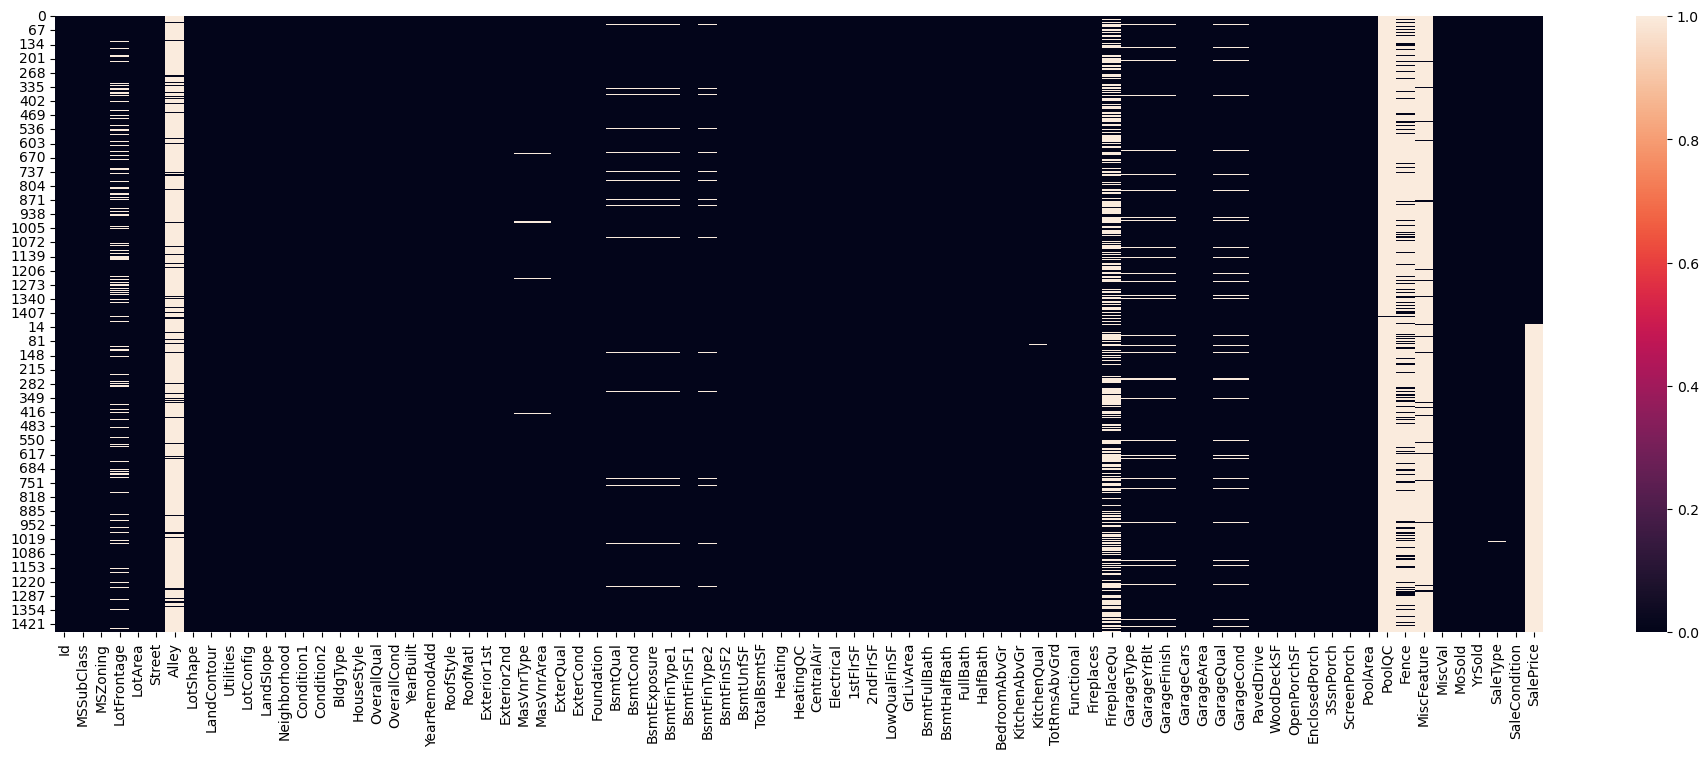

In [37]:
plt.figure(figsize=(24,8))
sns.heatmap(mdf.isnull())

In [38]:
#1.0 white means null value and -0.0 means non-null value

In [39]:
#now set thhe Id column as index 
mdf=mdf.set_index("Id")

In [40]:
null_Value=mdf.isnull().sum()
            
null_Value

MSSubClass          0
MSZoning            4
LotFrontage       486
LotArea             0
Street              0
Alley            2721
LotShape            0
LandContour         0
Utilities           2
LotConfig           0
LandSlope           0
Neighborhood        0
Condition1          0
Condition2          0
BldgType            0
HouseStyle          0
OverallQual         0
OverallCond         0
YearBuilt           0
YearRemodAdd        0
RoofStyle           0
RoofMatl            0
Exterior1st         1
Exterior2nd         1
MasVnrType         24
MasVnrArea         23
ExterQual           0
ExterCond           0
Foundation          0
BsmtQual           81
BsmtCond           82
BsmtExposure       82
BsmtFinType1       79
BsmtFinSF1          1
BsmtFinType2       80
BsmtFinSF2          1
BsmtUnfSF           1
TotalBsmtSF         1
Heating             0
HeatingQC           0
CentralAir          0
Electrical          1
1stFlrSF            0
2ndFlrSF            0
LowQualFinSF        0
GrLivArea 

In [41]:
# % of non-null value 
null_Value=mdf.isnull().sum()/mdf.shape[0]*100
            
null_Value
#0.0000000 meaning that their is not null value availble.

MSSubClass        0.000000
MSZoning          0.137033
LotFrontage      16.649538
LotArea           0.000000
Street            0.000000
Alley            93.216855
LotShape          0.000000
LandContour       0.000000
Utilities         0.068517
LotConfig         0.000000
LandSlope         0.000000
Neighborhood      0.000000
Condition1        0.000000
Condition2        0.000000
BldgType          0.000000
HouseStyle        0.000000
OverallQual       0.000000
OverallCond       0.000000
YearBuilt         0.000000
YearRemodAdd      0.000000
RoofStyle         0.000000
RoofMatl          0.000000
Exterior1st       0.034258
Exterior2nd       0.034258
MasVnrType        0.822199
MasVnrArea        0.787941
ExterQual         0.000000
ExterCond         0.000000
Foundation        0.000000
BsmtQual          2.774923
BsmtCond          2.809181
BsmtExposure      2.809181
BsmtFinType1      2.706406
BsmtFinSF1        0.034258
BsmtFinType2      2.740665
BsmtFinSF2        0.034258
BsmtUnfSF         0.034258
T

In [42]:
# now we are working with drop feautres 
#drop Columns Feature 

In [43]:
#missing value >= 50% 
missing_value_50_prec= null_Value[null_Value >50]
missing_value_50_prec

Alley          93.216855
PoolQC         99.657417
Fence          80.438506
MiscFeature    96.402878
dtype: float64

In [44]:
#we just check the value of Alley by counts
mdf["Alley"].value_counts()

Grvl    120
Pave     78
Name: Alley, dtype: int64

In [45]:
#we just check the value of PoolQC by counts
mdf["PoolQC"].value_counts()

Ex    4
Gd    4
Fa    2
Name: PoolQC, dtype: int64

In [46]:
#we just check the value of Fence by counts
mdf["Fence"].value_counts()

MnPrv    329
GdPrv    118
GdWo     112
MnWw      12
Name: Fence, dtype: int64

In [47]:
#missing value >= 20%  and less then 50 %
missing_value_20_prec= null_Value[(null_Value >20) & (null_Value <51)]
missing_value_20_prec

FireplaceQu    48.646797
SalePrice      49.982871
dtype: float64

In [48]:
#missing value >= 5%  and less then 21 %
missing_value_5_prec= null_Value[(null_Value >5) & (null_Value <21)]
missing_value_5_prec

LotFrontage     16.649538
GarageType       5.378554
GarageYrBlt      5.447071
GarageFinish     5.447071
GarageQual       5.447071
GarageCond       5.447071
dtype: float64

In [49]:
mdf["LotFrontage"].value_counts().head(2)

60.0    276
80.0    137
Name: LotFrontage, dtype: int64

<Axes: ylabel='Id'>

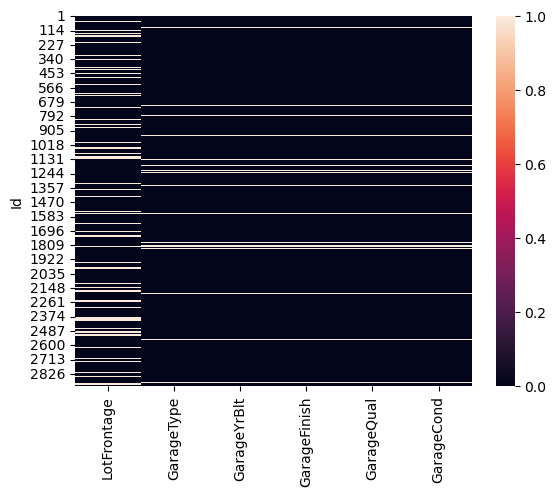

In [50]:
sns.heatmap(mdf[missing_value_5_prec.keys()].isnull())

In [51]:
# % of non-null value 
null_Value=mdf.isnull().sum()/mdf.shape[0]*100
            
null_Value

MSSubClass        0.000000
MSZoning          0.137033
LotFrontage      16.649538
LotArea           0.000000
Street            0.000000
Alley            93.216855
LotShape          0.000000
LandContour       0.000000
Utilities         0.068517
LotConfig         0.000000
LandSlope         0.000000
Neighborhood      0.000000
Condition1        0.000000
Condition2        0.000000
BldgType          0.000000
HouseStyle        0.000000
OverallQual       0.000000
OverallCond       0.000000
YearBuilt         0.000000
YearRemodAdd      0.000000
RoofStyle         0.000000
RoofMatl          0.000000
Exterior1st       0.034258
Exterior2nd       0.034258
MasVnrType        0.822199
MasVnrArea        0.787941
ExterQual         0.000000
ExterCond         0.000000
Foundation        0.000000
BsmtQual          2.774923
BsmtCond          2.809181
BsmtExposure      2.809181
BsmtFinType1      2.706406
BsmtFinSF1        0.034258
BsmtFinType2      2.740665
BsmtFinSF2        0.034258
BsmtUnfSF         0.034258
T

In [52]:
missing_value_null=null_Value[null_Value>0]
print("the null value is "),len(missing_value_null)

the null value is 


(None, 35)

In [53]:
missing_value_null.keys().isin(cat_fetr)

array([ True, False,  True,  True,  True,  True,  True, False,  True,
        True,  True,  True, False,  True, False, False, False,  True,
       False, False,  True,  True,  True,  True, False,  True, False,
       False,  True,  True,  True,  True,  True,  True, False])

In [54]:
missing_value_null[missing_value_null.keys().isin(cat_fetr)]

MSZoning         0.137033
Alley           93.216855
Utilities        0.068517
Exterior1st      0.034258
Exterior2nd      0.034258
MasVnrType       0.822199
BsmtQual         2.774923
BsmtCond         2.809181
BsmtExposure     2.809181
BsmtFinType1     2.706406
BsmtFinType2     2.740665
Electrical       0.034258
KitchenQual      0.034258
Functional       0.068517
FireplaceQu     48.646797
GarageType       5.378554
GarageFinish     5.447071
GarageQual       5.447071
GarageCond       5.447071
PoolQC          99.657417
Fence           80.438506
MiscFeature     96.402878
SaleType         0.034258
dtype: float64

In [55]:
cat_na_fetr=missing_value_null[missing_value_null.keys().isin(cat_fetr)]
print("we have total catagory fetures is ", len(cat_na_fetr))
cat_na_fetr

#MSZoning handinling 0.137033
#value counts getting.
mdf_mvi=mdf.copy()
mdf_mvi.shape
mdf["MSZoning"].value_counts()

we have total catagory fetures is  23


RL         2265
RM          460
FV          139
RH           26
C (all)      25
Name: MSZoning, dtype: int64

In [56]:
int_na_fetr = {key: value for key, value in missing_value_null.items() if key in int_fetr}
print("we have a total of", len(int_na_fetr), "integer features")


we have a total of 0 integer features


In [57]:
flot_na_fetr=missing_value_null[missing_value_null.keys().isin(flot_fetr)]
print("we have total flot fetures is ", len(flot_na_fetr))
flot_na_fetr

we have total flot fetures is  12


LotFrontage     16.649538
MasVnrArea       0.787941
BsmtFinSF1       0.034258
BsmtFinSF2       0.034258
BsmtUnfSF        0.034258
TotalBsmtSF      0.034258
BsmtFullBath     0.068517
BsmtHalfBath     0.068517
GarageYrBlt      5.447071
GarageCars       0.034258
GarageArea       0.034258
SalePrice       49.982871
dtype: float64

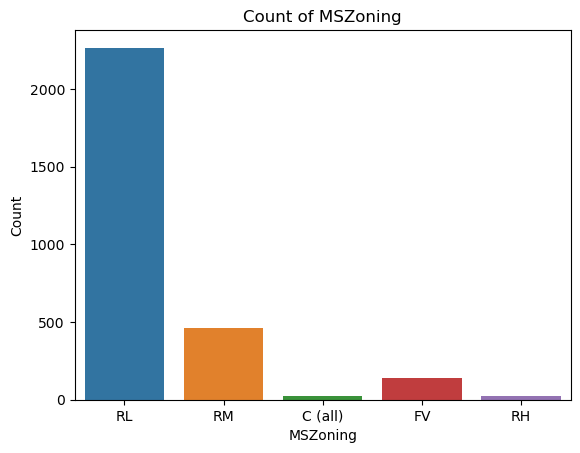

In [58]:
#specific value of dff data MSZoning 
sns.countplot(x="MSZoning", data=mdf)
plt.title("Count of MSZoning")
plt.xlabel("MSZoning")
plt.ylabel("Count")
plt.show()

In [59]:
mdf["MSZoning"].mode()[0]

'RL'

In [60]:
mszoning_mode = mdf_mvi["MSZoning"].mode()[0]
mszoning_mode

'RL'

In [61]:
mdf_mvi["MSZoning"].replace(np.nan, mszoning_mode, inplace=True)
mdf_mvi["MSZoning"].isnull().sum()

0

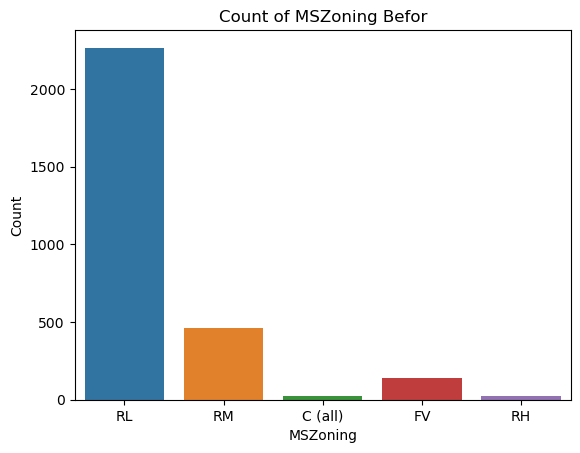

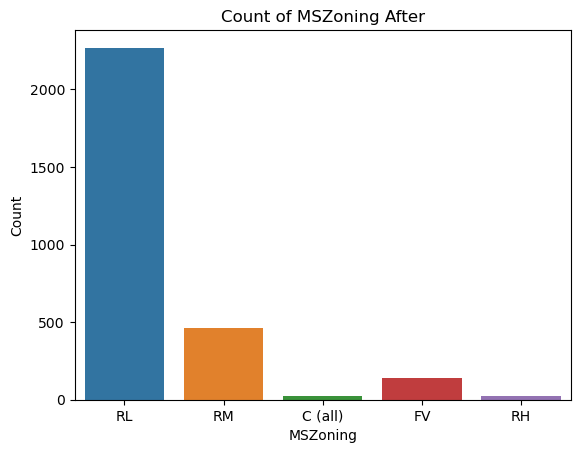

In [62]:
#specific value of dff data MSZoning 
sns.countplot(x="MSZoning", data=mdf)
plt.title("Count of MSZoning Befor")
plt.xlabel("MSZoning")
plt.ylabel("Count")
plt.show()
sns.countplot(x="MSZoning", data=mdf_mvi)
plt.title("Count of MSZoning After")
plt.xlabel("MSZoning")
plt.ylabel("Count")
plt.show()

In [63]:
mdf_mvi["Alley"].value_counts()

Grvl    120
Pave     78
Name: Alley, dtype: int64

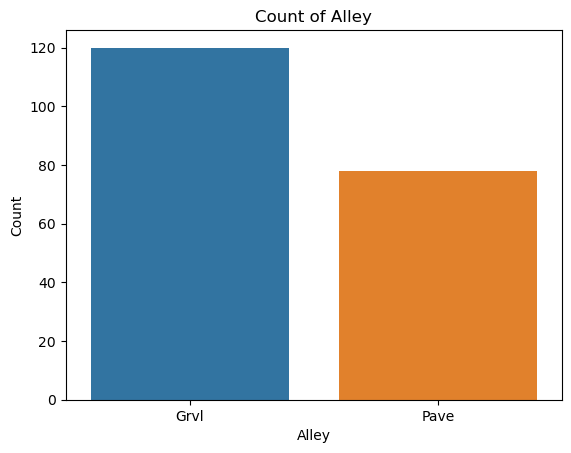

In [64]:
#specific value of dff data MSZoning 
sns.countplot(x="Alley", data=mdf_mvi)
plt.title("Count of Alley")
plt.xlabel("Alley")
plt.ylabel("Count")
plt.show()

In [65]:
allay_const="NA"
mdf_mvi["Alley"].replace(np.nan, allay_const, inplace=True)


In [66]:
mdf_mvi["Alley"].value_counts()

NA      2721
Grvl     120
Pave      78
Name: Alley, dtype: int64

In [67]:
#checking null values 
mdf_mvi["Alley"].isnull().sum()

0

In [68]:

mdf["LotFrontage"].mean()

69.30579531442663

In [69]:
lotfrontage_mean = mdf_mvi["LotFrontage"].mean()
mdf_mvi["LotFrontage"].replace(np.nan, lotfrontage_mean, inplace=True)
mdf_mvi["LotFrontage"].isnull().sum()

0

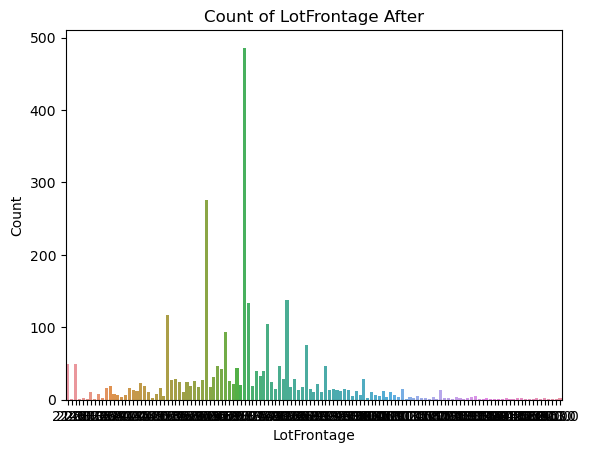

In [70]:
sns.countplot(x="LotFrontage", data=mdf_mvi)
plt.title("Count of LotFrontage After")
plt.xlabel("LotFrontage")
plt.ylabel("Count")
plt.show()

In [71]:
##handling with LotFrontage 16.649538 flot value 

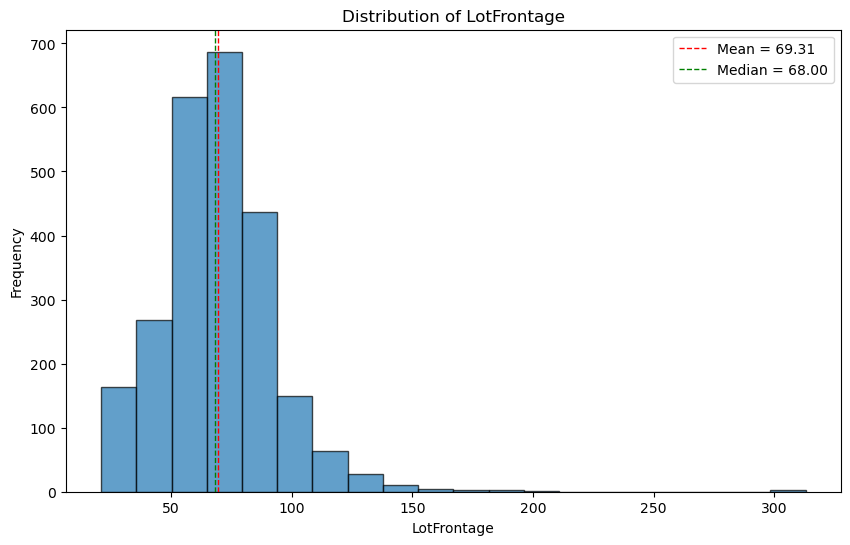

In [72]:
lot_frontage_column = mdf['LotFrontage']
mean_value = lot_frontage_column.mean()
median_value = lot_frontage_column.median()
plt.figure(figsize=(10, 6))
plt.hist(lot_frontage_column, bins=20, edgecolor='black', alpha=0.7)
plt.axvline(mean_value, color='red', linestyle='dashed', linewidth=1, label=f'Mean = {mean_value:.2f}')
plt.axvline(median_value, color='green', linestyle='dashed', linewidth=1, label=f'Median = {median_value:.2f}')
plt.xlabel('LotFrontage')
plt.ylabel('Frequency')
plt.title('Distribution of LotFrontage')
plt.legend()
plt.show()

In [73]:
#becouse of the data is downing from right and not curved then will impute the mean value

In [74]:
mean_value = lot_frontage_column.mean()
mdf_mvi["LotFrontage"].replace(np.nan, mean_value, inplace=True)
mdf_mvi["LotFrontage"].isnull().sum()

0

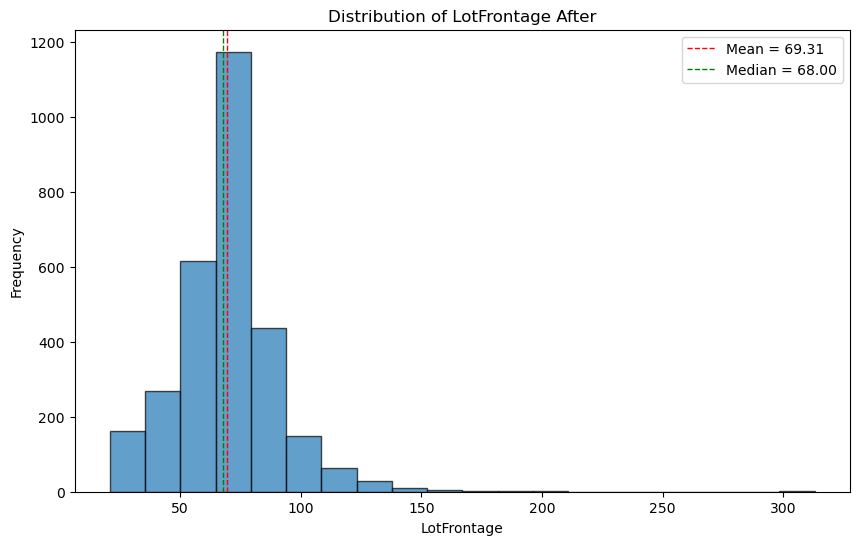

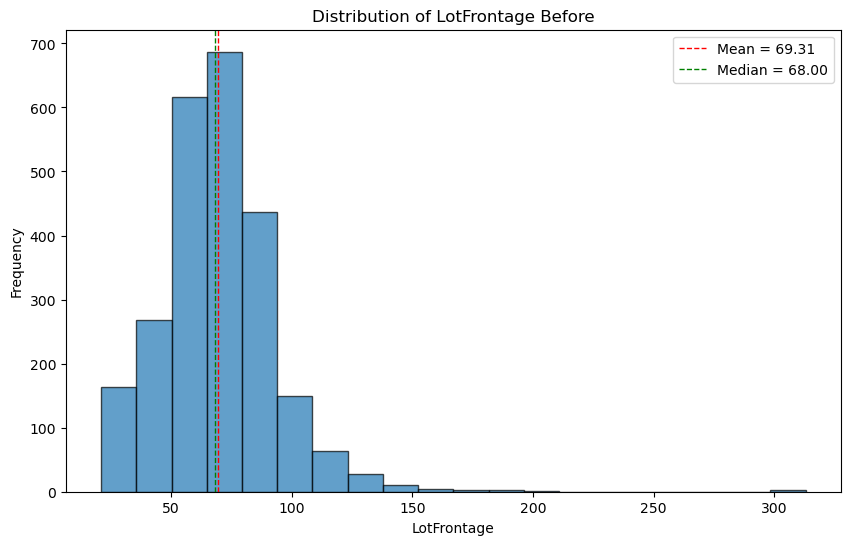

In [75]:
lot_frontage_column = mdf_mvi['LotFrontage']
plt.figure(figsize=(10, 6))
plt.hist(lot_frontage_column, bins=20, edgecolor='black', alpha=0.7)
plt.axvline(mean_value, color='red', linestyle='dashed', linewidth=1, label=f'Mean = {mean_value:.2f}')
plt.axvline(median_value, color='green', linestyle='dashed', linewidth=1, label=f'Median = {median_value:.2f}')
plt.xlabel('LotFrontage')
plt.ylabel('Frequency')
plt.title('Distribution of LotFrontage After')
plt.legend()
plt.show()
lot_frontage_column = mdf['LotFrontage']
mean_value = lot_frontage_column.mean()
median_value = lot_frontage_column.median()
plt.figure(figsize=(10, 6))
plt.hist(lot_frontage_column, bins=20, edgecolor='black', alpha=0.7)
plt.axvline(mean_value, color='red', linestyle='dashed', linewidth=1, label=f'Mean = {mean_value:.2f}')
plt.axvline(median_value, color='green', linestyle='dashed', linewidth=1, label=f'Median = {median_value:.2f}')
plt.xlabel('LotFrontage')
plt.ylabel('Frequency')
plt.title('Distribution of LotFrontage Before')
plt.legend()
plt.show()

In [76]:
##handling with Utilities 0.068517 flot value 
utilities_mode = mdf_mvi["Utilities"].mode()[0]
utilities_mode

'AllPub'

In [77]:
mdf_mvi["Utilities"].replace(np.nan, utilities_mode, inplace=True)
mdf_mvi["Utilities"].isnull().sum()

0

# no dealing with Exterior1st = 0.034258 and Exterior2nd = 0.034258

In [78]:
mdf_mvi["Exterior1st"].value_counts()

VinylSd    1025
MetalSd     450
HdBoard     442
Wd Sdng     411
Plywood     221
CemntBd     126
BrkFace      87
WdShing      56
AsbShng      44
Stucco       43
BrkComm       6
AsphShn       2
Stone         2
CBlock        2
ImStucc       1
Name: Exterior1st, dtype: int64

In [79]:
mdf_mvi["Exterior2nd"].value_counts()

VinylSd    1014
MetalSd     447
HdBoard     406
Wd Sdng     391
Plywood     270
CmentBd     126
Wd Shng      81
BrkFace      47
Stucco       47
AsbShng      38
Brk Cmn      22
ImStucc      15
Stone         6
AsphShn       4
CBlock        3
Other         1
Name: Exterior2nd, dtype: int64

In [80]:
exterior1st = mdf_mvi["Exterior1st"].mode()[0]
mdf_mvi["Exterior1st"].replace(np.nan, exterior1st, inplace=True)
mdf_mvi["Exterior1st"].isnull().sum()

0

In [81]:
exterior2nd = mdf_mvi["Exterior2nd"].mode()[0]
mdf_mvi["Exterior2nd"].replace(np.nan, exterior2nd, inplace=True)
mdf_mvi["Exterior2nd"].isnull().sum()

0

# no dealing with MasVnrArea = 0.787941 and MasVnrType = 0.822199

<Axes: ylabel='Id'>

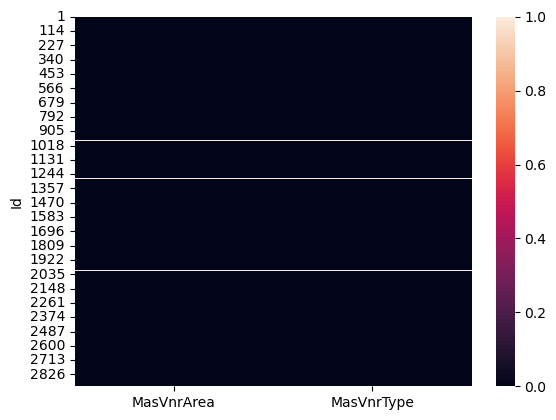

In [82]:
sns.heatmap(mdf[["MasVnrArea","MasVnrType"]].isnull())

In [83]:
mdf[mdf[["MasVnrArea","MasVnrType"]].isnull().any(axis=1)]

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
235,60,RL,NaN,7851,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,5,2002,2002,Gable,CompShg,VinylSd,VinylSd,NaN,NaN,Gd,TA,PConc,Gd,TA,No,GLQ,625.0,Unf,0.0,235.0,860.0,GasA,Ex,Y,SBrkr,860,1100,0,1960,1.0,0.0,2,1,4,1,Gd,8,Typ,2,TA,BuiltIn,2002.0,Fin,2.0,440.0,TA,TA,Y,288,48,0,0,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal,216500.0
530,20,RL,NaN,32668,Pave,NaN,IR1,Lvl,AllPub,CulDSac,Gtl,Crawfor,Norm,Norm,1Fam,1Story,6,3,1957,1975,Hip,CompShg,Wd Sdng,Stone,NaN,NaN,Gd,TA,PConc,TA,TA,No,Rec,1219.0,Unf,0.0,816.0,2035.0,GasA,TA,Y,SBrkr,2515,0,0,2515,1.0,0.0,3,0,4,2,TA,9,Maj1,2,TA,Attchd,1975.0,RFn,2.0,484.0,TA,TA,Y,0,0,200,0,0,0,NaN,NaN,NaN,0,3,2007,WD,Alloca,200624.0
651,60,FV,65.0,8125,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Somerst,Norm,Norm,1Fam,2Story,7,6,2007,2007,Gable,CompShg,CemntBd,CmentBd,NaN,NaN,Gd,TA,PConc,Gd,TA,No,Unf,0.0,Unf,0.0,813.0,813.0,GasA,Ex,Y,SBrkr,822,843,0,1665,0.0,0.0,2,1,3,1,Gd,7,Typ,0,NaN,Attchd,2007.0,RFn,2.0,562.0,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,5,2008,WD,Normal,205950.0
937,20,RL,67.0,10083,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,SawyerW,Norm,Norm,1Fam,1Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,NaN,NaN,Gd,TA,PConc,Gd,TA,No,GLQ,833.0,Unf,0.0,343.0,1176.0,GasA,Ex,Y,SBrkr,1200,0,0,1200,1.0,0.0,2,0,2,1,Gd,5,Typ,0,NaN,Attchd,2003.0,RFn,2.0,555.0,TA,TA,Y,0,41,0,0,0,0,NaN,NaN,NaN,0,8,2009,WD,Normal,184900.0
974,20,FV,95.0,11639,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,Somerst,Norm,Norm,1Fam,1Story,7,5,2007,2008,Gable,CompShg,CemntBd,CmentBd,NaN,NaN,Gd,TA,PConc,Gd,TA,No,Unf,0.0,Unf,0.0,1428.0,1428.0,GasA,Ex,Y,SBrkr,1428,0,0,1428,0.0,0.0,2,0,3,1,Gd,6,Typ,0,NaN,Attchd,2007.0,Fin,2.0,480.0,TA,TA,Y,0,120,0,0,0,0,NaN,NaN,NaN,0,12,2008,New,Partial,182000.0
978,120,FV,35.0,4274,Pave,Pave,IR1,Lvl,AllPub,Inside,Gtl,Somerst,Norm,Norm,TwnhsE,1Story,7,5,2006,2007,Gable,CompShg,VinylSd,VinylSd,NaN,NaN,Gd,TA,PConc,Gd,TA,No,GLQ,1106.0,Unf,0.0,135.0,1241.0,GasA,Ex,Y,SBrkr,1241,0,0,1241,1.0,0.0,1,1,1,1,Gd,4,Typ,0,NaN,Attchd,2007.0,Fin,2.0,569.0,TA,TA,Y,0,116,0,0,0,0,NaN,NaN,NaN,0,11,2007,New,Partial,199900.0
1244,20,RL,107.0,13891,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NridgHt,Norm,Norm,1Fam,1Story,10,5,2006,2006,Gable,CompShg,VinylSd,VinylSd,NaN,NaN,Ex,TA,PConc,Ex,Gd,Gd,GLQ,1386.0,Unf,0.0,690.0,2076.0,GasA,Ex,Y,SBrkr,2076,0,0,2076,1.0,0.0,2,1,2,1,Ex,7,Typ,1,Gd,Attchd,2006.0,Fin,3.0,850.0,TA,TA,Y,216,229,0,0,0,0,NaN,NaN,NaN,0,9,2006,New,Partial,465000.0
1279,60,RL,75.0,9473,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,8,5,2002,2002,Gable,CompShg,VinylSd,VinylSd,NaN,NaN,Gd,TA,PConc,Gd,TA,No,GLQ,804.0,Unf,0.0,324.0,1128.0,GasA,Ex,Y,SBrkr,1128,903,0,2031,1.0,0.0,2,1,3,1,Gd,7,Typ,1,Gd,Attchd,2002.0,RFn,2.0,577.0,TA,TA,Y,0,211,0,0,0,0,NaN,NaN,NaN,0,3,2008,WD,Normal,237000.0
1692,60,RL,NaN,12891,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Gilbert,Norm,Norm,1Fam,2Story,8,5,2002,2002,Gable,CompShg,VinylSd,VinylSd,NaN,NaN,Gd,TA,PConc,Ex,TA,No,GLQ,651.0,Unf,0.0,219.0,870.0,GasA,Ex,Y,SBrkr,878,1126,0,2004,1.0,0.0,2,1,4,1,Gd,8,Typ,1,Gd,BuiltIn,2002.0,Fin,3.0,644.0,TA,TA,Y,0,48,0,0,0,0,NaN,NaN,NaN,0,7,2009,WD,Nor

In [84]:
mdf["MasVnrType"].value_counts()

None       1742
BrkFace     879
Stone       249
BrkCmn       25
Name: MasVnrType, dtype: int64

In [85]:
masvnrtype = mdf_mvi["MasVnrType"].mode()[0]
mdf_mvi["MasVnrType"].replace(np.nan, masvnrtype, inplace=True)
mdf_mvi["MasVnrType"].isnull().sum()

0

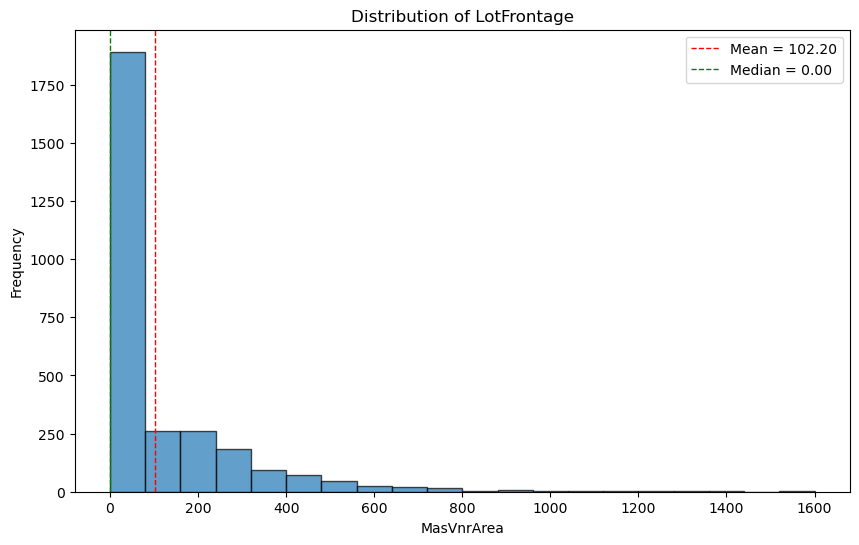

In [86]:
masvnrarea_column = mdf['MasVnrArea']
mean_value = masvnrarea_column.mean()
median_value = masvnrarea_column.median()
plt.figure(figsize=(10, 6))
plt.hist(masvnrarea_column, bins=20, edgecolor='black', alpha=0.7)
plt.axvline(mean_value, color='red', linestyle='dashed', linewidth=1, label=f'Mean = {mean_value:.2f}')
plt.axvline(median_value, color='green', linestyle='dashed', linewidth=1, label=f'Median = {median_value:.2f}')
plt.xlabel('MasVnrArea')
plt.ylabel('Frequency')
plt.title('Distribution of LotFrontage')
plt.legend()
plt.show()

In [87]:
#putting value 0 


In [88]:
masvnrarea_const = 0
mdf_mvi["MasVnrArea"].replace(np.nan, masvnrarea_const, inplace=True)
mdf_mvi["MasVnrArea"].isnull().sum()

0

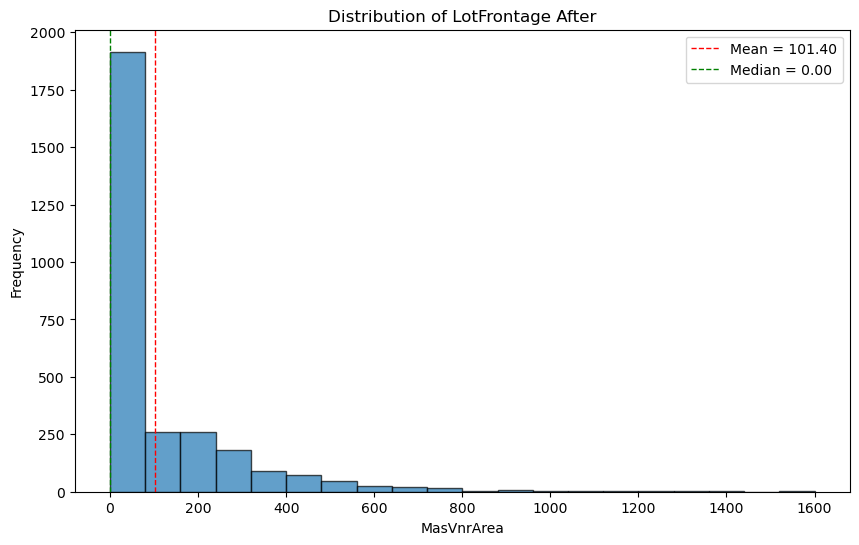

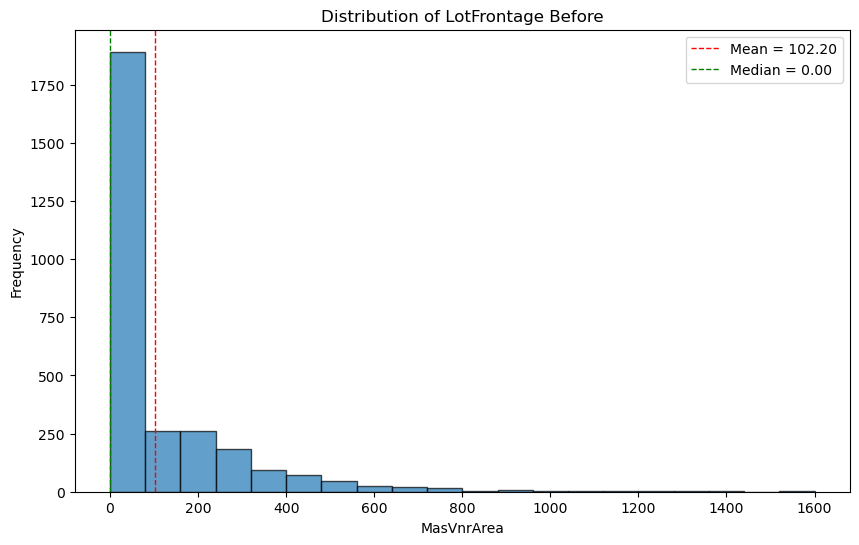

In [89]:
masvnrarea_column = mdf_mvi['MasVnrArea']
mean_value = masvnrarea_column.mean()
median_value = masvnrarea_column.median()
plt.figure(figsize=(10, 6))
plt.hist(masvnrarea_column, bins=20, edgecolor='black', alpha=0.7)
plt.axvline(mean_value, color='red', linestyle='dashed', linewidth=1, label=f'Mean = {mean_value:.2f}')
plt.axvline(median_value, color='green', linestyle='dashed', linewidth=1, label=f'Median = {median_value:.2f}')
plt.xlabel('MasVnrArea')
plt.ylabel('Frequency')
plt.title('Distribution of LotFrontage After')
plt.legend()
plt.show()
masvnrarea_column = mdf['MasVnrArea']
mean_value = masvnrarea_column.mean()
median_value = masvnrarea_column.median()
plt.figure(figsize=(10, 6))
plt.hist(masvnrarea_column, bins=20, edgecolor='black', alpha=0.7)
plt.axvline(mean_value, color='red', linestyle='dashed', linewidth=1, label=f'Mean = {mean_value:.2f}')
plt.axvline(median_value, color='green', linestyle='dashed', linewidth=1, label=f'Median = {median_value:.2f}')
plt.xlabel('MasVnrArea')
plt.ylabel('Frequency')
plt.title('Distribution of LotFrontage Before')
plt.legend()
plt.show()

## Now are dealing with basement data entities 

In [90]:
'''Cat_basement
BsmtQual         2.774923
BsmtCond         2.809181
BsmtExposure     2.809181
BsmtFinType1     2.706406
BsmtFinType2     2.740665

Num_Bastment 
BsmtFinSF2       0.034258
BsmtUnfSF        0.034258
TotalBsmtSF      0.034258
BsmtFullBath     0.068517
BsmtHalfBath     0.068517

'''

'Cat_basement\nBsmtQual         2.774923\nBsmtCond         2.809181\nBsmtExposure     2.809181\nBsmtFinType1     2.706406\nBsmtFinType2     2.740665\n\nNum_Bastment \nBsmtFinSF2       0.034258\nBsmtUnfSF        0.034258\nTotalBsmtSF      0.034258\nBsmtFullBath     0.068517\nBsmtHalfBath     0.068517\n\n'

In [91]:
cat_bsmnt = ["BsmtQual",        
"BsmtCond",        
"BsmtExposure",    
"BsmtFinType1",    
"BsmtFinType2"]  

num_bsmnt = ["BsmtFinSF1", "BsmtFinSF2",       
"BsmtUnfSF",        
"TotalBsmtSF",      
"BsmtFullBath",     
"BsmtHalfBath"]

<Axes: ylabel='Id'>

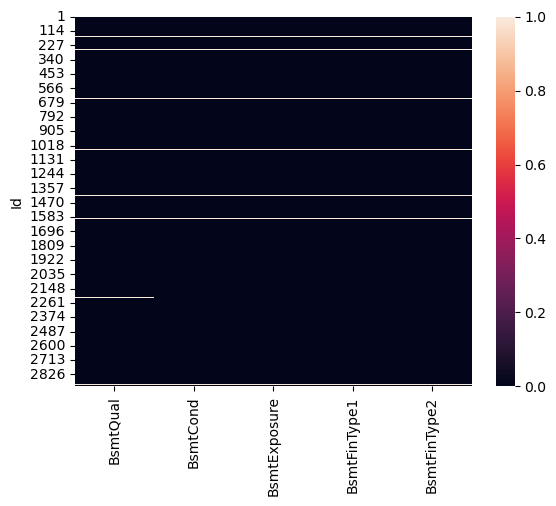

In [92]:
sns.heatmap(mdf[cat_bsmnt].isnull())

In [93]:
for feat in cat_bsmnt:
    print(f" Value cout of {feat}: {mdf[feat].value_counts()}")

 Value cout of BsmtQual: TA    1283
Gd    1209
Ex     258
Fa      88
Name: BsmtQual, dtype: int64
 Value cout of BsmtCond: TA    2606
Gd     122
Fa     104
Po       5
Name: BsmtCond, dtype: int64
 Value cout of BsmtExposure: No    1904
Av     418
Gd     276
Mn     239
Name: BsmtExposure, dtype: int64
 Value cout of BsmtFinType1: Unf    851
GLQ    849
ALQ    429
Rec    288
BLQ    269
LwQ    154
Name: BsmtFinType1, dtype: int64
 Value cout of BsmtFinType2: Unf    2493
Rec     105
LwQ      87
BLQ      68
ALQ      52
GLQ      34
Name: BsmtFinType2, dtype: int64


In [94]:
bsmtt_count = "NA"

for feat in cat_bsmnt:
    mdf_mvi[feat].fillna(bsmtt_count, inplace=True)

In [95]:
mdf_mvi[cat_bsmnt].isnull().sum()

BsmtQual        0
BsmtCond        0
BsmtExposure    0
BsmtFinType1    0
BsmtFinType2    0
dtype: int64

<Axes: ylabel='Id'>

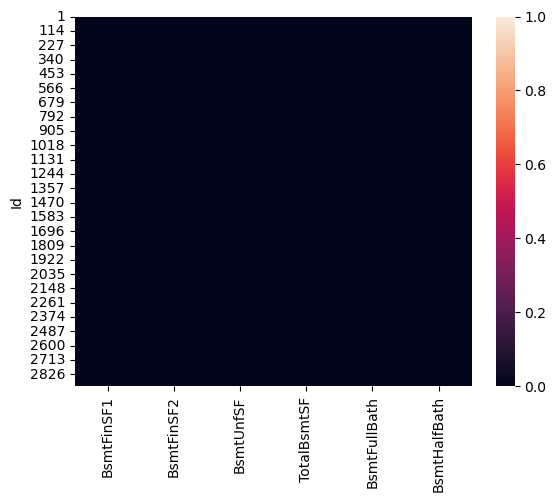

In [96]:
sns.heatmap(mdf[num_bsmnt].isnull())

In [97]:
mdb_bsmt=mdf[cat_bsmnt+num_bsmnt]
mdb_bsmt[mdb_bsmt.isnull().any(axis=1)]


,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,BsmtFullBath,BsmtHalfBath
Id,,,,,,,,,,,
18,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
40,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
91,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
103,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
157,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
183,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
260,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
333,Gd,TA,No,GLQ,NaN,1124.0,479.0,1603.0,3206.0,1.0,0.0
343,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0


In [98]:
bsmtt_num = 0

for feat in num_bsmnt:
    mdf_mvi[feat].fillna(bsmtt_num, inplace=True)

In [99]:
mdf_mvi[num_bsmnt].isnull().sum()

BsmtFinSF1      0
BsmtFinSF2      0
BsmtUnfSF       0
TotalBsmtSF     0
BsmtFullBath    0
BsmtHalfBath    0
dtype: int64

# Handling with Electrical = 0.034258 KitchenQual = 0.034258


In [100]:

mdf["Electrical"].value_counts()


SBrkr    2671
FuseA     188
FuseF      50
FuseP       8
Mix         1
Name: Electrical, dtype: int64

In [101]:
mdf_mvi["Electrical"].mode()[0]

'SBrkr'

In [102]:
electrical = "SBrkr"
mdf_mvi["Electrical"].replace(np.nan, electrical, inplace=True)
mdf_mvi["Electrical"].isnull().sum()

0

In [103]:
mdf["KitchenQual"].value_counts()


TA    1492
Gd    1151
Ex     205
Fa      70
Name: KitchenQual, dtype: int64

In [104]:
mdf_mvi["KitchenQual"].mode()[0]

'TA'

In [105]:
electrical = "TA"
mdf_mvi["KitchenQual"].replace(np.nan, electrical, inplace=True)
mdf_mvi["KitchenQual"].isnull().sum()

0

# Now handling remaining cat features 

In [106]:
"""Functional       0.068517 Mode 
FireplaceQu     48.646797 NA
PoolQC          99.657417 NA
Fence           80.438506 NA
MiscFeature     96.402878 NA
SaleType         0.034258 Mode"""

'Functional       0.068517 Mode \nFireplaceQu     48.646797 NA\nPoolQC          99.657417 NA\nFence           80.438506 NA\nMiscFeature     96.402878 NA\nSaleType         0.034258 Mode'

In [107]:

mdf["Functional"].value_counts()

Typ     2717
Min2      70
Min1      65
Mod       35
Maj1      19
Maj2       9
Sev        2
Name: Functional, dtype: int64

In [108]:
mdf_mvi["Functional"].mode()[0]

'Typ'

In [109]:
functional = "Typ"
mdf_mvi["Functional"].replace(np.nan, functional, inplace=True)
mdf_mvi["Functional"].isnull().sum()

0

In [110]:
mdf["SaleType"].value_counts()

WD       2525
New       239
COD        87
ConLD      26
CWD        12
ConLI       9
ConLw       8
Oth         7
Con         5
Name: SaleType, dtype: int64

In [111]:
mdf_mvi["SaleType"].mode()[0]

'WD'

In [112]:
saletype = "WD"
mdf_mvi["SaleType"].replace(np.nan, saletype, inplace=True)
mdf_mvi["SaleType"].isnull().sum()

0

In [113]:
other_futr=["FireplaceQu"
"PoolQC"
"Fence"
"MiscFeature"]

In [114]:
fireplacequ = "NA"
mdf_mvi["FireplaceQu"].replace(np.nan, fireplacequ, inplace=True)
mdf_mvi["FireplaceQu"].isnull().sum()

0

In [115]:
poolql = "NA"
mdf_mvi["PoolQC"].replace(np.nan, poolql, inplace=True)
mdf_mvi["PoolQC"].isnull().sum()

0

In [116]:
fence = "NA"
mdf_mvi["Fence"].replace(np.nan, fence, inplace=True)
mdf_mvi["Fence"].isnull().sum()

0

In [117]:
miscfeature = "NA"
mdf_mvi["MiscFeature"].replace(np.nan, miscfeature, inplace=True)
mdf_mvi["MiscFeature"].isnull().sum()

0

In [118]:
"""Cat_type
GarageType       5.378554
GarageFinish     5.447071
GarageQual       5.447071
GarageCond       5.447071

num_type

GarageYrBlt      5.447071
GarageCars       0.034258
GarageArea       0.034258
"""

'Cat_type\nGarageType       5.378554\nGarageFinish     5.447071\nGarageQual       5.447071\nGarageCond       5.447071\n\nnum_type\n\nGarageYrBlt      5.447071\nGarageCars       0.034258\nGarageArea       0.034258\n'

In [119]:
cat_garage = ["GarageType",        
"GarageFinish",        
"GarageQual",    
"GarageCond"]  

num_garage = ["GarageYrBlt", "GarageCars",       
"GarageArea"]

In [120]:
garage_num = 0

for feat in num_garage:
    mdf_mvi[feat].fillna(garage_num, inplace=True)

In [121]:
garage_cat = "NA"

for feat in cat_garage:
    mdf_mvi[feat].fillna(garage_cat, inplace=True)

In [122]:
mdf_mvi[cat_garage].isnull().sum()

GarageType      0
GarageFinish    0
GarageQual      0
GarageCond      0
dtype: int64

In [123]:
mdf_mvi[num_garage].isnull().sum()

GarageYrBlt    0
GarageCars     0
GarageArea     0
dtype: int64

In [124]:
mdf_mvi.isnull().sum()

MSSubClass          0
MSZoning            0
LotFrontage         0
LotArea             0
Street              0
Alley               0
LotShape            0
LandContour         0
Utilities           0
LotConfig           0
LandSlope           0
Neighborhood        0
Condition1          0
Condition2          0
BldgType            0
HouseStyle          0
OverallQual         0
OverallCond         0
YearBuilt           0
YearRemodAdd        0
RoofStyle           0
RoofMatl            0
Exterior1st         0
Exterior2nd         0
MasVnrType          0
MasVnrArea          0
ExterQual           0
ExterCond           0
Foundation          0
BsmtQual            0
BsmtCond            0
BsmtExposure        0
BsmtFinType1        0
BsmtFinSF1          0
BsmtFinType2        0
BsmtFinSF2          0
BsmtUnfSF           0
TotalBsmtSF         0
Heating             0
HeatingQC           0
CentralAir          0
Electrical          0
1stFlrSF            0
2ndFlrSF            0
LowQualFinSF        0
GrLivArea 

# Now we are applying the Transformation 
## Numarical Feature to Catagorical Feature

In [125]:
for_num_con= ["MSSubClass", "YrSold", "MoSold", "GarageYrBlt", "YearBuilt", "YearRemodAdd"]
for feat in for_num_con:
    print(f"{feat}: data type = {mdf_mvi[feat].dtype}")

MSSubClass: data type = int64
YrSold: data type = int64
MoSold: data type = int64
GarageYrBlt: data type = float64
YearBuilt: data type = int64
YearRemodAdd: data type = int64


In [126]:
mdf_mvi["MoSold"].unique()

array([ 2,  5,  9, 12, 10,  8, 11,  4,  1,  7,  3,  6])

In [127]:
calendar.month_abbr[12]

'Dec'

In [128]:
mdf_mvi["MoSold"]=mdf_mvi["MoSold"].apply(lambda x : calendar.month_abbr[x])

In [129]:
mdf_mvi["MoSold"].unique()

array(['Feb', 'May', 'Sep', 'Dec', 'Oct', 'Aug', 'Nov', 'Apr', 'Jan',
       'Jul', 'Mar', 'Jun'], dtype=object)

In [130]:
for feat in for_num_con:
    mdf_mvi[feat]=mdf_mvi[feat].astype(str)

In [131]:
for_num_con= ["MSSubClass", "YrSold", "MoSold", "GarageYrBlt", "YearBuilt", "YearRemodAdd"]
for feat in for_num_con:
    print(f"{feat}: data type = {mdf_mvi[feat].dtype}")
#now it converted into Numerical Feature to Categorical 

MSSubClass: data type = object
YrSold: data type = object
MoSold: data type = object
GarageYrBlt: data type = object
YearBuilt: data type = object
YearRemodAdd: data type = object


## Catagorical Feature to Numarical Feature
### Ordinal Encoding 


In [132]:
ordinal_end_var=["Utilities",
"ExterQual",
"ExterCond",
"BsmtQual",
"BsmtCond",
"BsmtExposure",
"BsmtFinType1",
"BsmtFinSF1",
"BsmtFinType2",
"HeatingQC",
"KitchenQual",
"Functional",
"FireplaceQu",
"GarageFinish",
"GarageQual",
"GarageCond",
"PavedDrive",
"PoolQC"]
print("The total number of features to convert ordinal numarical format", len(ordinal_end_var))

The total number of features to convert ordinal numarical format 18


In [133]:
#Dealing with ExterQual
mdf_mvi["ExterQual"].unique()

array(['Gd', 'TA', 'Ex', 'Fa'], dtype=object)

In [134]:
mdf_mvi["ExterQual"]=mdf_mvi["ExterQual"].astype(CategoricalDtype(categories=["Po","Fa","TA","Gd","Ex"],ordered=True)).cat.codes

In [135]:
#Re-Checking and verfication 
mdf_mvi["ExterQual"].value_counts()

2    1798
3     979
4     107
1      35
Name: ExterQual, dtype: int64

In [136]:
#Dealing with Utilities
mdf_mvi["Utilities"].unique()

array(['AllPub', 'NoSeWa'], dtype=object)

In [137]:
mdf_mvi["Utilitiess"]=mdf_mvi["Utilities"].astype(CategoricalDtype(categories=["ELO","NoSeWa","NoSewr","AllPub"],ordered=True)).cat.codes

In [138]:
mdf_mvi["Utilitiess"].value_counts()

3    2918
1       1
Name: Utilitiess, dtype: int64

In [139]:
#Dealing with ExterCond
mdf_mvi["ExterCond"].unique()

array(['TA', 'Gd', 'Fa', 'Po', 'Ex'], dtype=object)

In [140]:
mdf_mvi["ExterCond"]=mdf_mvi["ExterCond"].astype(CategoricalDtype(categories=["Po","Fa","TA","Gd","Ex"],ordered=True)).cat.codes

In [141]:
mdf_mvi["ExterCond"].unique()

array([2, 3, 1, 0, 4], dtype=int8)

In [142]:
#Dealing with BsmtQual
mdf_mvi["BsmtQual"].unique()

array(['Gd', 'TA', 'Ex', 'NA', 'Fa'], dtype=object)

In [143]:
mdf_mvi["BsmtQual"]=mdf_mvi["BsmtQual"].astype(CategoricalDtype(categories=["NA","Po","Fa","TA","Gd","Ex"],ordered=True)).cat.codes

In [144]:
mdf_mvi["BsmtQual"].unique()

array([4, 3, 5, 0, 2], dtype=int8)

In [145]:
#Dealing with BsmtCond
mdf_mvi["BsmtCond"].unique()

array(['TA', 'Gd', 'NA', 'Fa', 'Po'], dtype=object)

In [146]:
mdf_mvi["BsmtCond"]=mdf_mvi["BsmtCond"].astype(CategoricalDtype(categories=["NA","Po","Fa","TA","Gd"],ordered=True)).cat.codes

In [147]:
#Dealing with BsmtCond
mdf_mvi["BsmtCond"].unique()

array([3, 4, 0, 2, 1], dtype=int8)

In [148]:
#Dealing with BsmtExposure
mdf_mvi["BsmtExposure"].unique()

array(['No', 'Gd', 'Mn', 'Av', 'NA'], dtype=object)

In [149]:
mdf_mvi["BsmtExposure"]=mdf_mvi["BsmtExposure"].astype(CategoricalDtype(categories=["NA","No","Mn","Av","Gd"],ordered=True)).cat.codes

In [150]:

mdf_mvi["BsmtExposure"].unique()

array([1, 4, 2, 3, 0], dtype=int8)

In [151]:
#Dealing with BsmtFinType1
mdf_mvi["BsmtFinType1"].unique()

array(['GLQ', 'ALQ', 'Unf', 'Rec', 'BLQ', 'NA', 'LwQ'], dtype=object)

In [152]:
mdf_mvi["BsmtFinType1"]=mdf_mvi["BsmtFinType1"].astype(CategoricalDtype(categories=["NA","Unf","LwQ","Rec","BLQ","ALQ","GLQ"],ordered=True)).cat.codes

In [153]:
mdf_mvi["BsmtFinType1"].unique()

array([6, 5, 1, 3, 4, 0, 2], dtype=int8)

In [154]:
#Dealing with BsmtFinType2
mdf_mvi["BsmtFinType2"].unique()

array(['Unf', 'BLQ', 'NA', 'ALQ', 'Rec', 'LwQ', 'GLQ'], dtype=object)

In [155]:
mdf_mvi["BsmtFinType2"]=mdf_mvi["BsmtFinType2"].astype(CategoricalDtype(categories=["NA","Unf","LwQ","Rec","BLQ","ALQ","GLQ"],ordered=True)).cat.codes

In [156]:
mdf_mvi["BsmtFinType2"].unique()

array([1, 4, 0, 5, 3, 2, 6], dtype=int8)

In [157]:
#Dealing with HeatingQC
mdf_mvi["HeatingQC"].unique()


array(['Ex', 'Gd', 'TA', 'Fa', 'Po'], dtype=object)

In [158]:
mdf_mvi["HeatingQC"]=mdf_mvi["HeatingQC"].astype(CategoricalDtype(categories=["Po","Fa","TA","Gd","Ex"],ordered=True)).cat.codes

In [159]:
mdf_mvi["HeatingQC"].unique()

array([4, 3, 2, 1, 0], dtype=int8)

In [160]:
#Dealing with KitchenQual
mdf_mvi["KitchenQual"].unique()

array(['Gd', 'TA', 'Ex', 'Fa'], dtype=object)

In [161]:
mdf_mvi["KitchenQual"]=mdf_mvi["KitchenQual"].astype(CategoricalDtype(categories=["Po","Fa","TA","Gd","Ex"],ordered=True)).cat.codes

In [162]:
mdf_mvi["KitchenQual"].unique()

array([3, 2, 4, 1], dtype=int8)

In [163]:
#Dealing with Functional
mdf_mvi["Functional"].unique()

array(['Typ', 'Min1', 'Maj1', 'Min2', 'Mod', 'Maj2', 'Sev'], dtype=object)

In [164]:
mdf_mvi["Functional"]=mdf_mvi["Functional"].astype(CategoricalDtype(categories=["Sal","Sev","Maj2","Maj1","Mod","Min2","Min1","Typ"],ordered=True)).cat.codes

In [165]:
mdf_mvi["Functional"].unique()

array([7, 6, 3, 5, 4, 2, 1], dtype=int8)

In [166]:
#Dealing with FireplaceQu
mdf_mvi["FireplaceQu"].unique()

array(['NA', 'TA', 'Gd', 'Fa', 'Ex', 'Po'], dtype=object)

In [167]:
mdf_mvi["FireplaceQu"]=mdf_mvi["FireplaceQu"].astype(CategoricalDtype(categories=["NA","Po","Fa","TA","Gd","Ex"],ordered=True)).cat.codes

In [168]:
mdf_mvi["FireplaceQu"].unique()

array([0, 3, 4, 2, 5, 1], dtype=int8)

In [169]:
#Dealing with GarageFinish
mdf_mvi["GarageFinish"].unique()

array(['RFn', 'Unf', 'Fin', 'NA'], dtype=object)

In [170]:
mdf_mvi["GarageFinish"]=mdf_mvi["GarageFinish"].astype(CategoricalDtype(categories=["NA","Unf","RFn","Fin"],ordered=True)).cat.codes

In [171]:
mdf_mvi["GarageFinish"].unique()

array([2, 1, 3, 0], dtype=int8)

In [172]:
#Dealing with GarageQual
mdf_mvi["GarageQual"].unique()

array(['TA', 'Fa', 'Gd', 'NA', 'Ex', 'Po'], dtype=object)

In [173]:
mdf_mvi["GarageQual"]=mdf_mvi["GarageQual"].astype(CategoricalDtype(categories=["NA","Po","Fa","TA","Gd","Ex"],ordered=True)).cat.codes

In [174]:
mdf_mvi["GarageQual"].unique()

array([3, 2, 4, 0, 5, 1], dtype=int8)

In [175]:

#Dealing with GarageCond
mdf_mvi["GarageCond"].unique()



array(['TA', 'Fa', 'NA', 'Gd', 'Po', 'Ex'], dtype=object)

In [176]:
mdf_mvi["GarageCond"]=mdf_mvi["GarageCond"].astype(CategoricalDtype(categories=["NA","Po","Fa","TA","Gd","Ex"],ordered=True)).cat.codes

In [177]:
mdf_mvi["GarageCond"].unique()

array([3, 2, 0, 4, 1, 5], dtype=int8)

In [178]:

#Dealing with PavedDrive
mdf_mvi["PavedDrive"].unique()






array(['Y', 'N', 'P'], dtype=object)

In [179]:
mdf_mvi["PavedDrive"]=mdf_mvi["PavedDrive"].astype(CategoricalDtype(categories=["N","P","Y"],ordered=True)).cat.codes

In [180]:
mdf_mvi["PavedDrive"].unique()

array([2, 0, 1], dtype=int8)

In [181]:
#Dealing with PoolQC
mdf_mvi["PoolQC"].unique()

array(['NA', 'Ex', 'Fa', 'Gd'], dtype=object)

In [182]:
mdf_mvi["PoolQC"]=mdf_mvi["PoolQC"].astype(CategoricalDtype(categories=["NA","Fa","TA","Gd","Ex"],ordered=True)).cat.codes

In [183]:
mdf_mvi["PoolQC"].unique()

array([0, 4, 1, 3], dtype=int8)

###now Ordinal no is done 

In [184]:
mdf_mvi.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2919 entries, 1 to 2919
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     2919 non-null   object 
 1   MSZoning       2919 non-null   object 
 2   LotFrontage    2919 non-null   float64
 3   LotArea        2919 non-null   int64  
 4   Street         2919 non-null   object 
 5   Alley          2919 non-null   object 
 6   LotShape       2919 non-null   object 
 7   LandContour    2919 non-null   object 
 8   Utilities      2919 non-null   object 
 9   LotConfig      2919 non-null   object 
 10  LandSlope      2919 non-null   object 
 11  Neighborhood   2919 non-null   object 
 12  Condition1     2919 non-null   object 
 13  Condition2     2919 non-null   object 
 14  BldgType       2919 non-null   object 
 15  HouseStyle     2919 non-null   object 
 16  OverallQual    2919 non-null   int64  
 17  OverallCond    2919 non-null   int64  
 18  YearBuil

## Nominal  Encoding 
### One hot Technique

In [185]:
df_en = mdf_mvi.copy()
ob_features = df_en.select_dtypes(include="object").columns.tolist()
print("The total object features are:", len(ob_features))
print("The features are:\n", ob_features)

The total object features are: 33
The features are:
 ['MSSubClass', 'MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'Foundation', 'Heating', 'CentralAir', 'Electrical', 'GarageType', 'GarageYrBlt', 'Fence', 'MiscFeature', 'MoSold', 'YrSold', 'SaleType', 'SaleCondition']


In [186]:
df_en[ob_features].head(2)

,MSSubClass,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,Foundation,Heating,CentralAir,Electrical,GarageType,GarageYrBlt,Fence,MiscFeature,MoSold,YrSold,SaleType,SaleCondition
Id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,60,RL,Pave,NA,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,PConc,GasA,Y,SBrkr,Attchd,2003.0,NA,NA,Feb,2008,WD,Normal
2,20,RL,Pave,NA,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,CBlock,GasA,Y,SBrkr,Attchd,1976.0,NA,NA,May,2007,WD,Normal


In [187]:
print("Shape of DF Before encoding", df_en.shape)
df_en=pd.get_dummies(df_en,
                    columns=ob_features,
                    prefix=ob_features,
                    drop_first=True)
print("Shape of DF After encoding", df_en.shape)

Shape of DF Before encoding (2919, 81)
Shape of DF After encoding (2919, 514)


In [188]:
df_en.head(2)

,LotFrontage,LotArea,OverallQual,OverallCond,MasVnrArea,ExterQual,ExterCond,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,HeatingQC,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,MiscVal,SalePrice,Utilitiess,MSSubClass_150,MSSubClass_160,MSSubClass_180,MSSubClass_190,MSSubClass_20,MSSubClass_30,MSSubClass_40,MSSubClass_45,MSSubClass_50,MSSubClass_60,MSSubClass_70,MSSubClass_75,MSSubClass_80,MSSubClass_85,MSSubClass_90,MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,Street_Pave,Alley_NA,Alley_Pave,LotShape_IR2,LotShape_IR3,LotShape_Reg,LandContour_HLS,LandContour_Low,LandContour_Lvl,Utilities_NoSeWa,LotConfig_CulDSac,LotConfig_FR2,LotConfig_FR3,LotConfig_Inside,LandSlope_Mod,LandSlope_Sev,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_IDOTRR,Neighborhood_MeadowV,Neighborhood_Mitchel,Neighborhood_NAmes,Neighborhood_NPkVill,Neighborhood_NWAmes,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,Condition1_Feedr,Condition1_Norm,Condition1_PosA,Condition1_PosN,Condition1_RRAe,Condition1_RRAn,Condition1_RRNe,Condition1_RRNn,Condition2_Feedr,Condition2_Norm,Condition2_PosA,Condition2_PosN,Condition2_RRAe,Condition2_RRAn,Condition2_RRNn,BldgType_2fmCon,BldgType_Duplex,BldgType_Twnhs,BldgType_TwnhsE,HouseStyle_1.5Unf,HouseStyle_1Story,HouseStyle_2.5Fin,HouseStyle_2.5Unf,HouseStyle_2Story,HouseStyle_SFoyer,HouseStyle_SLvl,YearBuilt_1875,YearBuilt_1879,YearBuilt_1880,YearBuilt_1882,YearBuilt_1885,YearBuilt_1890,YearBuilt_1892,YearBuilt_1893,YearBuilt_1895,YearBuilt_1896,YearBuilt_1898,YearBuilt_1900,YearBuilt_1901,YearBuilt_1902,YearBuilt_1904,YearBuilt_1905,YearBuilt_1906,YearBuilt_1907,YearBuilt_1908,YearBuilt_1910,YearBuilt_1911,YearBuilt_1912,YearBuilt_1913,YearBuilt_1914,YearBuilt_1915,YearBuilt_1916,YearBuilt_1917,YearBuilt_1918,YearBuilt_1919,YearBuilt_1920,YearBuilt_1921,YearBuilt_1922,YearBuilt_1923,YearBuilt_1924,YearBuilt_1925,YearBuilt_1926,YearBuilt_1927,YearBuilt_1928,YearBuilt_1929,YearBuilt_1930,YearBuilt_1931,YearBuilt_1932,YearBuilt_1934,YearBuilt_1935,YearBuilt_1936,YearBuilt_1937,YearBuilt_1938,YearBuilt_1939,YearBuilt_1940,YearBuilt_1941,YearBuilt_1942,YearBuilt_1945,YearBuilt_1946,YearBuilt_1947,YearBuilt_1948,YearBuilt_1949,YearBuilt_1950,YearBuilt_1951,YearBuilt_1952,YearBuilt_1953,YearBuilt_1954,YearBuilt_1955,YearBuilt_1956,YearBuilt_1957,YearBuilt_1958,YearBuilt_1959,YearBuilt_1960,YearBuilt_1961,YearBuilt_1962,YearBuilt_1963,YearBuilt_1964,YearBuilt_1965,YearBuilt_1966,YearBuilt_1967,YearBuilt_1968,YearBuilt_1969,YearBuilt_1970,YearBuilt_1971,YearBuilt_1972,YearBuilt_1973,YearBuilt_1974,YearBuilt_1975,YearBuilt_1976,YearBuilt_1977,YearBuilt_1978,YearBuilt_1979,YearBuilt_1980,YearBuilt_1981,YearBuilt_1982,YearBuilt_1983,YearBuilt_1984,YearBuilt_1985,YearBuilt_1986,YearBuilt_1987,YearBuilt_1988,YearBuilt_1989,YearBuilt_1990,YearBuilt_1991,YearBuilt_1992,YearBuilt_1993,YearBuilt_1994,YearBuilt_1995,YearBuilt_1996,YearBuilt_1997,YearBuilt_1998,YearBuilt_1999,YearBuilt_2000,YearBuilt_2001,YearBuilt_2002,YearBuilt_2003,YearBuilt_2004,YearBuilt_2005,YearBuilt_2006,YearBuilt_2007,YearBuilt_2008,YearBuilt_2009,YearBuilt_2010,YearRemodAdd_1951,YearRemodAdd_1952,YearRemodAdd_1953,YearRemodAdd_1954,YearRemodAdd_1955,YearRemodAdd_1956,YearRemodAdd_1957,YearRemodAdd_1958,YearRemodAdd_1959,YearRemodAdd_1960,YearRemodAdd_1961,YearRemodAdd_1962,YearRemodAdd_1963,YearRemodAdd_1964,YearRemodAdd_1965,YearRemodAdd_1966,YearRemodAdd_19

In [189]:
df_en.select_dtypes(include="object").columns.tolist()

[]

## Split Data for Traning and Testing


In [190]:
len_train=train.shape[0]

In [191]:
X_train = df_en[:len_train].drop("SalePrice", axis=1)
Y_train = df_en["SalePrice"][:len_train]

X_test = df_en[len_train:].drop("SalePrice", axis=1)

print("Shape of X_train data is:", X_train.shape)
print("Shape of Y_train data is:", Y_train.shape)
print("Shape of X_test data is:", X_test.shape)


Shape of X_train data is: (1460, 513)
Shape of Y_train data is: (1460,)
Shape of X_test data is: (1459, 513)


In [192]:
## Split is done 

# Feature Scalling 

In [193]:
sc=StandardScaler()

In [194]:
#formula is Z =(x-u)/s

In [195]:
sc.fit(X_train)
X_train=sc.transform(X_train)
X_test=sc.transform(X_test)

In [196]:
X_train[:3,:]

array([[-0.22335706, -0.20714171,  0.65147924, ..., -0.11785113,
         0.4676514 , -0.30599503],
       [ 0.45789401, -0.09188637, -0.07183611, ..., -0.11785113,
         0.4676514 , -0.30599503],
       [-0.08710685,  0.07347998,  0.65147924, ..., -0.11785113,
         0.4676514 , -0.30599503]])

In [197]:
X_test[:3,:]

array([[ 0.45789401,  0.11076257, -0.79515147, ..., -0.11785113,
         0.4676514 , -0.30599503],
       [ 0.50331075,  0.37584985, -0.07183611, ..., -0.11785113,
         0.4676514 , -0.30599503],
       [ 0.18539358,  0.33205282, -0.79515147, ..., -0.11785113,
         0.4676514 , -0.30599503]])

In [198]:
## Carring for Deploment must be ensure 
#sc.mean_
#sc.feature_names_in_
#sc.n_features_in_
#sc.n_samples_seen_
#sc.scale_
#sc.var_
#sc.with_mean
#sc.with_std

In [199]:
#choseing the model according to requairtments 
## recmnded site: https://scikit-learn.org/stable/index.html 

# Train ML Model Now

In [200]:
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import SGDRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.isotonic import IsotonicRegression
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.isotonic import IsotonicRegression
from xgboost import XGBRegressor


In [201]:
svr =SVR
lr = LinearRegression
sgdr = SGDRegressor
knr = KNeighborsRegressor
gpr = GaussianProcessRegressor
dtr = DecisionTreeRegressor
gbr = GradientBoostingRegressor
ir = IsotonicRegression
mlpr = MLPRegressor
rfr =  RandomForestRegressor



In [202]:
model = {
    'SVR': SVR(),
    'LinearRegression': LinearRegression(),
    'SGDRegressor': SGDRegressor(),
    'KNeighborsRegressor': KNeighborsRegressor(),
    'GaussianProcessRegressor': GaussianProcessRegressor(),
    'DecisionTreeRegressor': DecisionTreeRegressor(),
    'GradientBoostingRegressor': GradientBoostingRegressor(),
    'IsotonicRegression': IsotonicRegression(),
    'MLPRegressor': MLPRegressor(),
    'RandomForestRegressor': RandomForestRegressor()
}

In [203]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import make_scorer, r2_score

def test_model(model, X_train=X_train, y_train=Y_train):
    cv = KFold(n_splits = 3, shuffle=True, random_state = 45)
    r2 = make_scorer(r2_score)
    r2_val_score = cross_val_score(model, X_train, Y_train, cv=cv, scoring = r2)
    score = [r2_val_score.mean()]
    return score

In [204]:
import sklearn.linear_model as linear_model
LR = linear_model.LinearRegression()
test_model(LR)

[-4.6469958072229026e+23]

In [205]:
rdg = linear_model.Ridge()
test_model(rdg)

[0.578497346874471]

In [206]:
lasso = linear_model.Lasso(alpha=1e-4)
test_model(lasso)

/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.309e+11, tolerance: 6.264e+08
  model = cd_fast.enet_coordinate_descent(
/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.174e+11, tolerance: 5.972e+08
  model = cd_fast.enet_coordinate_descent(
/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.656e+11, tolerance: 6.178e

[0.5241786937858197]

In [207]:
from sklearn.svm import SVR
svr = SVR(kernel='rbf')
test_model(svr)

[-0.051897427616267366]

In [208]:
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
params = {'kernel': ['rbf'],
         'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
         'C': [0.1, 1, 10, 100, 1000],
         'epsilon': [1, 0.2, 0.1, 0.01, 0.001, 0.0001]}
rand_search = RandomizedSearchCV(svr, param_distributions=params, n_jobs=-1, cv=11)
rand_search.fit(X_train, Y_train)
rand_search.best_score_

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


0.19521129571155219

In [209]:
rand_search.best_estimator_

SVR(C=1000, epsilon=0.0001, gamma=0.001)

In [210]:
svr_reg1=SVR(C=10, cache_size=200, coef0=0.0, degree=3, epsilon=0.1, gamma=0.001,
    kernel='rbf', max_iter=-1, shrinking=True, tol=0.001, verbose=False)
test_model(svr_reg1)

[-0.04954022005465982]

In [211]:
svr_reg= SVR(C=100, cache_size=200, coef0=0.0, degree=3, epsilon=0.01, gamma=0.0001,
    kernel='rbf', max_iter=-1, shrinking=True, tol=0.001, verbose=False)
test_model(svr_reg)

[-0.04741071184888105]

In [212]:
import xgboost
#xgb_reg=xgboost.XGBRegressor()
xgb_reg = xgboost.XGBRegressor(bbooster='gbtree', random_state=51)
test_model(xgb_reg)

[19:53:51] WARNING: ../src/learner.cc:767: 
Parameters: { "bbooster" } are not used.

[19:53:52] WARNING: ../src/learner.cc:767: 
Parameters: { "bbooster" } are not used.

[19:53:53] WARNING: ../src/learner.cc:767: 
Parameters: { "bbooster" } are not used.



[0.8276229125451358]

In [213]:
xgb2_reg=xgboost.XGBRegressor(n_estimators= 899,
 mon_child_weight= 2,
 max_depth= 4,
 learning_rate= 0.05,
 booster= 'gbtree')

test_model(xgb2_reg)

[19:53:54] WARNING: ../src/learner.cc:767: 
Parameters: { "mon_child_weight" } are not used.

[19:54:01] WARNING: ../src/learner.cc:767: 
Parameters: { "mon_child_weight" } are not used.

[19:54:07] WARNING: ../src/learner.cc:767: 
Parameters: { "mon_child_weight" } are not used.



[0.8413474409197107]

In [214]:
xgb2_reg.fit(X_train,Y_train)
y_pred = np.exp(xgb2_reg.predict(X_test)).round(2)
submit_test = pd.concat([test['Id'],pd.DataFrame(y_pred)], axis=1)
submit_test.columns=['Id', 'SalePrice']
submit_test.to_csv('sample_submission.csv', index=False)
submit_test

"""
Rank: 1444
Red AI Productionnovice 
tier
0.12278
5
now
Your Best Entry 
Your submission scored 0.13481, which is not an improvement of your best score. Keep trying!"""

[19:54:15] WARNING: ../src/learner.cc:767: 
Parameters: { "mon_child_weight" } are not used.



/tmp/ipykernel_20/47623405.py:2: RuntimeWarning: overflow encountered in exp
  y_pred = np.exp(xgb2_reg.predict(X_test)).round(2)


'\nRank: 1444\nRed AI Productionnovice \ntier\n0.12278\n5\nnow\nYour Best Entry \nYour submission scored 0.13481, which is not an improvement of your best score. Keep trying!'

In [215]:
svr_reg.fit(X_train,Y_train)
y_pred = np.exp(svr_reg.predict(X_test)).round(2)
submit_test = pd.concat([test['Id'],pd.DataFrame(y_pred)], axis=1)
submit_test.columns=['Id', 'SalePrice']
submit_test.to_csv('sample_submission.csv', index=False)
submit_test

"""
file: sample_submission-v1-fs
rank: 1444
Red AI Productionnovice tier
0.12278
4
3m
Your Best Entry 
You advanced 140 places on the leaderboard!

Your submission scored 0.12278, which is an improvement of your previous score of 0.12484. Great job!"""

/tmp/ipykernel_20/1376018191.py:2: RuntimeWarning: overflow encountered in exp
  y_pred = np.exp(svr_reg.predict(X_test)).round(2)


'\nfile: sample_submission-v1-fs\nrank: 1444\nRed AI Productionnovice tier\n0.12278\n4\n3m\nYour Best Entry \nYou advanced 140 places on the leaderboard!\n\nYour submission scored 0.12278, which is an improvement of your previous score of 0.12484. Great job!'

In [216]:
import pickle

pickle.dump(svr_reg, open('model_house_price_prediction.csv', 'wb'))
model_house_price_prediction = pickle.load(open('model_house_price_prediction.csv', 'rb'))
model_house_price_prediction.predict(X_test)

array([162882.73677344, 163017.19397199, 163471.44336179, ...,
       163199.29214591, 162866.41151322, 163554.47974395])

In [217]:
test_model(model_house_price_prediction)

[-0.04741071184888105]